계속 할루시네이션을 감지하는 문제

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from rag.pdf import PDFRetrievalChain

pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

In [3]:
import ragas
ragas.__version__

'0.2.14'

In [4]:
from langgraph.graph import StateGraph
from typing import Type, TypedDict, Annotated
from crewai import Agent, Task, Crew
from crewai.process import Process
from langchain_openai import ChatOpenAI
from crewai.tools import tool
import os
from langchain_community.utilities import ArxivAPIWrapper

from tavily import TavilyClient
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid



### Tool

In [5]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 문서 평가를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM 초기화 및 함수 호출을 통한 구조화된 출력 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# 문서 검색결과 평가기 생성 
retrieval_grader = grade_prompt | structured_llm_grader


In [6]:
# from crewai.tools import tool
# from pydantic import BaseModel, Field
# from langchain_openai import ChatOpenAI
# from langchain_core.prompts import ChatPromptTemplate

# # CrewAI가 사용하는 형태로 재정의
# @tool("retriever_tool")
# def retriever_tool(question: str) -> str:
#     """2023년 12월에 출판된 AI 트렌드 PDF에서 정보를 검색하고, 관련성이 높은 결과만 반환합니다."""
    
#     print("\n===[Retrieval TOOL, Search relevant_docs]===\n")
    
#     # PDF에서 문서 검색
#     docs = pdf_retriever.invoke(question)
    
#     if not docs:
#         return "관련된 문서를 찾지 못했습니다."

#     # 검색된 문서 평가
#     relevant_docs = []
#     for doc in docs:
#         grade_result = retrieval_grader.invoke({"document": doc.page_content, "question": question})
#         if grade_result.binary_score == "yes":
#             relevant_docs.append(doc)

#     # 평가 후 관련 문서가 없다면 메시지 반환
#     if not relevant_docs:
#         return "질문과 관련성이 높지 않아 제외되었습니다."
    
#     print(f"Final retrieved {len(relevant_docs)} relevant documents.\n")

#     # 필터링된 문서들을 하나의 문자열로 반환
#     return "\n\n".join([
#         f"{doc.page_content}\n(출처: {doc.metadata.get('source', 'N/A')} / 페이지: {doc.metadata.get('page', 'N/A')})"
#         for doc in relevant_docs
#     ])

In [7]:
# retriever = retriever_tool.func("삼성전자 생성형 ai")
# print(retriever)

In [8]:
# Define other tools
@tool("tavily_tool")
def tavily_tool(keyword: str) -> str:
    """Collect recent news for the given query."""
    print("\n===[Web search]===\n")
    tavily_client = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])
    search_results = tavily_client.search(query=keyword, topic="general", days=30)
    print(search_results)
    return search_results

# @tool("academic_tool")
# def academic_tool(query: str):
#     """Academic paper search tool."""
#     print("\n===[Arxiv Paper Search]===\n")
#     arxiv = ArxivAPIWrapper()
    
#     docs = arxiv.load(query)
#     print(docs)
#     return docs

In [9]:
from langchain_community.retrievers import ArxivRetriever

@tool("academic_tool")
def academic_tool(query: str) -> list[dict]:
    """Academic paper search tool using ArxivRetriever."""  # ✅ 요게 필수!
    arxiv_retriever = ArxivRetriever(
        load_all_available_meta=True,
        get_full_documents=True
    )
    docs = arxiv_retriever.invoke(query)
    return docs

In [10]:
# Define LLM
llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# === 1. 메시지 상태 정의 ===
# Define the State class
class CrewAIState(TypedDict):
    topic: Annotated[str, "The user's query to retrieve law information"]
    documents: Annotated[list, "Retrieved documents related to the query"]
    generation: Annotated[str, "LLM generated answer"]
    agents_list: Annotated[list, "List of dynamically added agents"]
    
    # # persona
    # role: Annotated[str, "Role of the agent"]
    # goal: Annotated[str, "Goal of the agent"]
    # backstory: Annotated[str, "Backstory of the agent"]

class Persona(TypedDict):
    role: Annotated[str, "Role of the agent"]
    goal: Annotated[str, "Goal of the agent"]
    backstory: Annotated[str, "Backstory of the agent"]

In [12]:
def add_agents(state: CrewAIState) -> CrewAIState:
    """
    실행 시작 시 사용자의 입력을 받아 새로운 Agent를 추가하는 노드
    """
    # 기존 Agents 리스트 (없을 경우 빈 리스트)
    #updated_agents_list = state.get("agents_list", [])

    # 사용자의 입력값에서 `role`, `goal`, `backstory` 가져오기


    new_agent = {
        "role": state["role"],
        "goal": state["goal"],
        "backstory": state["backstory"]
    }

    # ✅ 새로운 Agent 추가 (기존 목록 유지)
    state["agents_list"].append(new_agent)

    return {
       "agents_list": state["agents_list"]
    }

### 분석가 자동화로 만들기

In [13]:
from typing import List, Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Persona(TypedDict):
    role: Annotated[str, "Role of the agent"]
    goal: Annotated[str, "Goal of the agent"]
    backstory: Annotated[str, "Backstory of the agent"]

In [14]:
# 분석가들의 목록: Analysts의 class를 받는다.
class Perspectives(BaseModel):
    analysts: List[Persona] = Field(
        description="Comprehensive list of analysts with their roles, goals and backstory."
    )

class GenerateAnalystsState(TypedDict):
    topic: str # 주제
    max_analysts: int # 분석가 수 
    human_analyst_feedback: str # 사람 피드백
    

In [ ]:
from langgraph.graph import END
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage, AIMessage, ChatMessage, ToolMessage
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

# 분석가 생성 프롬프트
analyst_instructions = """
You are tasked with creating a set of AI analyst personas. 

Follow these instructions carefully:
1. First, review the research topic:

{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 

{human_analyst_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme.
"""

# 분석가 생성 노드
def create_analysts(state: GenerateAnalystsState):
    """분석가 페르소나를 생성하는 함수"""
    
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback", "")
    
    # Perspectives은, 분석가들의 집합
    structured_llm = llm.with_structured_output(Perspectives)
    
    # 분석가 생성을 위한 시스템 프롬프트 구성. 위에서 선언한 topic, human_analyst_feedback, max_analysts가 필요
    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts
    )
    
    # llm을 호출하여 분석가 페르소나 생성. Perspective의 객체를 이미 가지고 있다.
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content="Generate the set of analysts.")]
    )
    
    # 생성된 분석가 목록을 상태에 저장
    return {"analysts": analysts.analysts}
    # 첫 번째 analysts는 GenerateAnalystsState의 딕셔너리 키이고,
    # 두 번째 analysts는 LLM이 반환한 Perspectives 객체지만, 어디에도 속하지 못하는거고 ,
    # 세 번째 analysts는 LLM이 생성한 두번째 analysts를 Perpectives의 analysts에 넣는다는 것. 즉 Perspectives.analysts의 속성

# 사용자 피드백 노드(상태 업데이트를 진행할 예정이므로, 내용은 비워 두어도 무방)
def human_feedback(state: Persona):
    """사용자 피드백을 받기 위한 중단점 노드"""
    pass

# 인간 피드백 여부에 따라 워크플로우의 다음 단계를 결정하는 함수
def should_continue(state: Persona):
     """워크플로우의 다음 단계를 결정하는 함수"""
     
     human_feedback = state.get("human_analyst_feedback", None)
     if human_feedback:
         return "create_analysts"
     
     return END

In [16]:
# 실행
###111
state = {
    "topic": "Long-Context 기반 LLM (e.g. Gemini, Claude) vs RAG 시스템 비교 실험",
    "max_analysts": 3,
    #"human_analyst_feedback": "Focus on regulatory challenges, algorithmic trading, and market stability."
}
analyst = create_analysts(state)
analyst

# # 실행예시
# state = {
#     "topic": "The impact of AI on financial markets",
#     "max_analysts": 3,
#     "human_analyst_feedback": "Focus on regulatory challenges, algorithmic trading, and market stability."
# }
# output = create_analysts(state)
# output


{'analysts': [{'role': 'Data Scientist',
   'goal': 'Evaluate the performance metrics of Long-Context LLMs vs RAG systems to identify strengths and weaknesses in real-world applications.',
   'backstory': 'With a background in computational linguistics and years of experience in machine learning, this analyst has always been fascinated by how AI processes language. Having worked on multiple AI-driven projects, they are particularly interested in the scalability and efficiency of large models.'},
  {'role': 'Product Manager',
   'goal': 'Determine which AI system (LLMs or RAG) is more suitable for enhancing user experience in a specific application.',
   'backstory': 'This analyst comes from a tech startup environment where they launched several AI-powered products. They understand the importance of customer satisfaction and are keen on aligning AI capabilities with user needs, ensuring that the chosen system truly enhances the user experience.'},
  {'role': 'Research Scholar',
   'goal

In [17]:
analyst["analysts"]

[{'role': 'Data Scientist',
  'goal': 'Evaluate the performance metrics of Long-Context LLMs vs RAG systems to identify strengths and weaknesses in real-world applications.',
  'backstory': 'With a background in computational linguistics and years of experience in machine learning, this analyst has always been fascinated by how AI processes language. Having worked on multiple AI-driven projects, they are particularly interested in the scalability and efficiency of large models.'},
 {'role': 'Product Manager',
  'goal': 'Determine which AI system (LLMs or RAG) is more suitable for enhancing user experience in a specific application.',
  'backstory': 'This analyst comes from a tech startup environment where they launched several AI-powered products. They understand the importance of customer satisfaction and are keen on aligning AI capabilities with user needs, ensuring that the chosen system truly enhances the user experience.'},
 {'role': 'Research Scholar',
  'goal': 'Conduct an in-de

In [18]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from crewai import Agent, Task, Crew, Process
from langchain.chat_models import ChatOpenAI

# === 1. 메시지 상태 정의 ===
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], add_messages]

# === 2. LLM 모델 설정 ===
llm = ChatOpenAI(model="gpt-4o-mini")


# === 3. CrewAI 실행 함수 (LangGraph 노드) ===
def crewai(state: CrewAIState) -> CrewAIState:
    """
    문서를 검색해 CrewAI를 실행하고, 결과를 다시 상태에 추가하는 LangGraph 노드.
    """
    # 1. 메시지 상태에서 사용자 입력 메시지 추출
    # user_messages = [msg.content for msg in state["question"] if isinstance(msg, HumanMessage)]
    # # user_messages = [msg.content for msg in state["messages"] if isinstance(msg, HumanMessage)]
    # question = user_messages[-1] if user_messages else "최신 AI 기술 트렌드 조사 후 뉴스레터 작성해줘"
    
    topic = state["topic"]
    
    #지금은 2025년 3월입니다.

      # 5. CrewAI 실행 결과 가져오기
    # retrieved_text = retriever_tool.func(question)  # 기본 PDF 검색
    news_text = tavily_tool.func(topic)  # 최신 뉴스 검색
    academic_text = academic_tool.func(topic)  # 논문 검색

    documents = []

    # 🔍 `retriever_tool` 결과 추가
    # if isinstance(retrieved_text, str) and retrieved_text.strip():
    #     documents.append({"content": retrieved_text, "source": "retriever_tool"})

    # 🔍 `tavily_tool` 결과 추가 (최신 뉴스)
    # if isinstance(news_text, str) and news_text.strip():
    #     documents.append({"content": news_text, "source": "tavily_tool"})

    # # 🔍 `academic_tool` 결과 추가 (논문 검색)
    # if isinstance(academic_text, str) and academic_text.strip():
    #     documents.append({"content": academic_text, "source": "academic_tool"})    
    
    if isinstance(news_text, list):
        documents.extend(news_text)

    if isinstance(academic_text, list):
        documents.extend(academic_text)    

     # ✅ CrewAI Agents 리스트 생성 (state["agents_list"] 기반)
    agents = [
        Agent(
            role=agent_info["role"],
            goal=agent_info["goal"],
            backstory=agent_info["backstory"],
            tools=[tavily_tool, academic_tool],  # 필요하면 tools 추가 가능
            verbose=False,
            max_iter=20,
            llm=llm,
        )
        for agent_info in state["agents_list"]
    ]

    if not agents:
        print("❌ 실행할 Agent가 없습니다. 최소 1명 이상의 Agent를 추가하세요.")
        return state
    
        
    # ✅ CrewAI Task 설정
    tasks = [
        Task(
            description=(
                """
                You will be given a conversation about {topic} between an analyst and an expert.\n\n"
                Your goal is to generate a well-structured query for use in retrieval and/or web-search related to the conversation.\n\n
                First, analyze the full conversation regarding {topic}.\n\n
                Pay particular attention to the final question posed by the analyst about {topic}.\n\n
                Convert this final question into a well-structured web search query.
                
                # Aanswer_instructions
                You are an expert being interviewed by an analyst.
                Here is analyst area of focus: {Persona.goal}.
                You goal is to answer a question poconcised by the interviewer.
                
                To answer question, use this context:
                {documents}

                When answering questions, follow these guidelines:
                
                1. Use only the information provided in the context.     
                2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.
                3. The context contain sources at the topic of each individual document.
                4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 
                5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
                6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
                [1] assistant/docs/llama3_1.pdf, page 7 
                And skip the addition of the brackets as well as the Document source preamble in your citation
                
                You are a query analyst. Your task is to analyze a conversation between an analyst and an expert on the topic: **{topic}**.
                --
                # 🎯 Goal:
                Identify the final question posed by the analyst, and rewrite it into a **clear, keyword-rich, search-optimized web query**.

                # 📌 Notes:
                - A URL to the source is required.
                - Do NOT generate answers.
                - Do NOT include explanations.
                - Focus only on transforming the final question into a single-line search query.
            """
                
            ),
            # "특히 PDF, 논문, 뉴스 검색 도구를 통해 다양한 관점에서 정보를 확보하세요. "
            expected_output="Well-structured web search query",
            # expected_output="정보 요약 및 출처 포함된 조사 결과",
            agent=agent
        )
        for agent in agents
    ]



    # 6. LangGraph 메시지 상태 업데이트

    writer = Agent(
        role="Expert Technical Writer",
        goal="To generate well-structured, informative, and properly cited markdown reports based on analyst memos and source documents.",
        backstory=(
            "You are a professional technical writer. Your job is to transform research memos and retrieved source documents into comprehensive markdown reports. "
            "Your work must be clearly organized, citation-rich, and easy to understand for both technical and non-technical readers."
        ),
        verbose=True,
        allow_delegation=True,
        llm=llm,
    )
   
    write = Task(
        description=f"""
# 🧠 Your Role  
You are a technical writer tasked with creating a markdown report on the topic: **{topic}**.  
You are provided with analyst memos and retrieved documents from academic and web sources.

---

## 🧾 Report Format

The report must include the following **markdown** sections:

## 📌 Section Instructions

### Summary
- Provide context and briefly explain what the report is about.
- Highlight novel, interesting, or surprising findings.
- Include citations like [1], [2] where appropriate.

### Key Concepts
- Define key terms and concepts for readers unfamiliar with the topic.
- Keep definitions concise (2–4 lines each).
- Use bullet points.
- Include 4–8 important concepts.

### Timeline of Developments
- List important events or technological advancements in chronological order.
- Include dates (year or month/year) if available.
- Each entry should be 1–2 sentences.

### Comprehensive Analysis
- Analyze the information in-depth (target **800+ words**).
- Use sub-sections if helpful.
- Support points with data, examples, or quotes from the documents.
- Use bullet points or numbered lists where appropriate.

### Common Challenges & Pitfalls
- List practical problems, limitations, or common errors related to the topic.
- Provide 3–5 concise bullet points.
- Optionally include mitigation tips.

---

## 🔍 Citation Guidelines

- Use **only** the content provided in the documents.
- Add citations in square brackets (e.g., [1], [2]) after factual claims.
- Each document has a `"source"` field containing either a URL or file path.
- Do not cite the same source multiple times under different numbers.
- At the end of the report, include a `### Sources` section with this format:
- The URL path must be present.

## ✅ Final Checks

- Do NOT include a preamble.
- Do NOT mention analyst names.
- Maintain a professional tone throughout.
- Use markdown formatting consistently.
- Start with the `## Insights` title.
- All content should be based on the documents below.


---

## 📂 Documents to Use

{documents}
""",
        expected_output="A fully structured markdown report on {topic} including citations and informative sections.",
        agent=writer,
        output_file="./Langgraph_with_crewai2.md"
    )
    
    # 4. Crew 정의 및 실행
    crew = Crew(
        agents= agents + [writer],
        tasks= tasks + [write],
        verbose=True,
        process=Process.sequential,
        share_crew=True,
        memory=True,
    )

    # Crew 실행 후 결과 저장
    result = crew.kickoff()
    
    # 4. Crew 실행 결과에서 올바르게 'generation'을 추출
    generation = (
        "\n".join([str(res) for res in result]) if isinstance(result, list)  # 리스트 응답 처리
        else result.content if hasattr(result, "content")  # CrewAI 응답 객체 처리
        else str(result)  # 일반적인 경우
    )
    
    
  
    return {
        "topic": state["topic"],
        "generation": generation,
        "documents": documents  # ✅ CrewAI 실행 결과를 LangGraph에서 활용 가능하게 변환
    }

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_42252\1347226292.py:13: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="gpt-4o-mini")


In [19]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(CrewAIState)

workflow.add_node("crewai", crewai)
#workflow.add_node("transform_query", transform_query)  # 쿼리 변환

workflow.add_edge(START, "crewai")
# workflow.add_conditional_edges(
#     "crewai",
#     hallucination_check,
#     {
#         "hallucination": "crewai",  # Hallucination 발생 시 재생성
#         "relevant": END,  # 답변의 관련성 여부 통과
#         "not relevant": "transform_query",  # 답변의 관련성 여부 통과 실패 시 쿼리 변환
#         "terminate": END,  # 🚨 강제 종료
#     },
# )
# workflow.add_edge("transform_query", "crewai")
workflow.add_edge("crewai", END)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

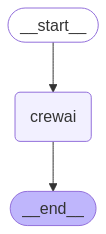

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
analyst["analysts"]

[{'role': 'Data Scientist',
  'goal': 'Evaluate the performance metrics of Long-Context LLMs vs RAG systems to identify strengths and weaknesses in real-world applications.',
  'backstory': 'With a background in computational linguistics and years of experience in machine learning, this analyst has always been fascinated by how AI processes language. Having worked on multiple AI-driven projects, they are particularly interested in the scalability and efficiency of large models.'},
 {'role': 'Product Manager',
  'goal': 'Determine which AI system (LLMs or RAG) is more suitable for enhancing user experience in a specific application.',
  'backstory': 'This analyst comes from a tech startup environment where they launched several AI-powered products. They understand the importance of customer satisfaction and are keen on aligning AI capabilities with user needs, ensuring that the chosen system truly enhances the user experience.'},
 {'role': 'Research Scholar',
  'goal': 'Conduct an in-de

In [22]:
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
import uuid
###111
topic = "Long-Context 기반 LLM (e.g. Gemini, Claude) vs RAG 시스템 비교 실험"
messages = f"So you said you were writing an article on {topic}?"
#messages = [HumanMessage(content=f"So you said you were writing an article on {topic}?")]

config = RunnableConfig(recursion_limit=20, configurable={"thread_id": uuid.uuid4()})

input_state = {
    "topic": messages,
    "agents_list": analyst["analysts"],
}

# 그래프 실행
output = app.invoke(input_state, config=config)

# 출력 예시
print("🧠 Generated Answer:\n", output.get("generation", ""))
print("📚 Used Contexts:\n", [
    doc["content"] if isinstance(doc, dict) else doc.page_content
    for doc in output.get("documents", [])
])



===[Web search]===

{'query': 'So you said you were writing an article on Long-Context 기반 LLM (e.g. Gemini, Claude) vs RAG 시스템 비교 실험?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'RAG vs Long-Context LLMs: Approaches for Real-World Applications', 'url': 'https://blog.premai.io/rag-vs-long-context-llms-which-approach-excels-in-real-world-applications/', 'content': 'This article compares Retrieval-Augmented Generation (RAG) with Long-Context Large Language Models (LLMs) in managing extensive data and complex queries, highlighting key technical differences and applications. To better understand the comparative performance of Retrieval-Augmented Generation (RAG) and Long-Context (LC) LLMs across various tasks, we present the following visualizations. This comparison highlights how Long-Context (LC) LLMs, Retrieval-Augmented Generation (RAG), and the hybrid approach (SELF-ROUTE) perform in different real-world scenarios. Long Context RAG Performance of

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-09 17:57:28][🚀 CREW 'CREW' STARTED, 861D0266-6740-4E3F-BEA2-DBE79D5758FB]: 2025-04-09 17:57:28.034869
 
[2025-04-09 17:57:28][📋 TASK STARTED: 
                YOU WILL BE GIVEN A CONVERSATION ABOUT {TOPIC} BETWEEN AN ANALYST AND AN EXPERT.

"
                YOUR GOAL IS TO GENERATE A WELL-STRUCTURED QUERY FOR USE IN RETRIEVAL AND/OR WEB-SEARCH RELATED TO THE CONVERSATION.


                FIRST, ANALYZE THE FULL CONVERSATION REGARDING {TOPIC}.


                PAY PARTICULAR ATTENTION TO THE FINAL QUESTION POSED BY THE ANALYST ABOUT {TOPIC}.


                CONVERT THIS FINAL QUESTION INTO A WELL-STRUCTURED WEB SEARCH QUERY.
                
                # AANSWER_INSTRUCTIONS
                YOU ARE AN EXPERT BEING INTERVIEWED BY AN ANALYST.
                HERE IS ANALYST AREA OF FOCUS: {PERSONA.GOAL}.
                YOU GOAL IS TO ANSWER A QUESTION POCONCISED BY THE INTERVIEWER.
                
                TO ANSWER QUESTION, USE THIS CONTEXT:
              

In [23]:
from IPython.display import Markdown

# 최종 보고서 가져오기
report = "Langgraph_with_crewai2.md"

# 마크다운 형식으로 최종 보고서 출력
display(Markdown(report))

# Comparative Report on Long-Context LLMs and RAG Systems

## Summary
In the rapidly advancing field of artificial intelligence, two prominent strategies for enhancing the capabilities of language models have emerged: Long-Context Large Language Models (LLMs) and Retrieval-Augmented Generation (RAG) systems. This report provides a comprehensive comparison of these two approaches, focusing on their theoretical foundations, performance metrics in real-world applications, strengths and weaknesses, as well as common challenges and pitfalls.

## Key Concepts
- **Long-Context LLMs**: These models, such as Gemini and Claude, are designed to process extensive text inputs effectively. They leverage advanced architectures to maintain context over long sequences, enabling nuanced understanding and generation.
- **Retrieval-Augmented Generation (RAG)**: RAG systems enhance the capabilities of LLMs by incorporating external information retrieval mechanisms. This approach allows models to access and utilize relevant data in real-time, improving response accuracy and relevance.

## Timeline of Developments
- **2020**: Introduction of transformer models, which laid the groundwork for LLMs.
- **2022**: Release of models like GPT-3.5, showcasing increased context understanding.
- **2023**: Emergence of RAG systems, integrating retrieval mechanisms into LLMs.
- **2024**: Proliferation of Long-Context models such as Claude and Gemini, demonstrating superior performance in complex tasks.

## Comprehensive Analysis
### Performance Metrics
*Long-Context LLMs* have shown significant improvements in handling complex queries with long dependencies. Performance metrics such as accuracy, response time, and contextual understanding are critical. For instance, studies indicate that Long-Context models outperform traditional LLMs in maintaining coherence over lengthy discussions (Balaguer et al., 2024).

*RAG systems* excel in accuracy by integrating real-time data retrieval. Research indicates that RAG-enhanced models achieve higher accuracy rates in question-answering tasks compared to standalone LLMs. For example, a comparative study demonstrated that RAG models improved accuracy by 6 percentage points over Long-Context models in specific applications (Ahmed et al., 2025).

### Strengths and Weaknesses
#### Long-Context LLMs
**Strengths**:
- Enhanced contextual awareness over extended inputs.
- Superior performance in generating coherent narratives.

**Weaknesses**:
- Increased computational requirements.
- Limited by the maximum context window, leading to potential information loss.

#### RAG Systems
**Strengths**:
- Real-time access to external information, enhancing accuracy.
- Flexibility in adapting to diverse domains due to dynamic data retrieval.

**Weaknesses**:
- Complexity in integrating retrieval mechanisms.
- Potential issues with information overload and relevance dilution.

### Real-World Applications
Long-Context LLMs are effectively utilized in creative fields, such as content generation and storytelling, where narrative coherence is crucial. RAG systems find applications in customer support and knowledge management, where accurate and timely information retrieval is essential (Saha et al., 2025).

## Common Challenges & Pitfalls
Both Long-Context LLMs and RAG systems face challenges related to model explainability, potential biases in training data, and the need for rigorous testing frameworks to ensure reliability in production environments. Ensuring the models do not propagate misinformation remains a critical concern.

## Sources
1. Balaguer, A., et al. (2024). RAG vs Fine-tuning: Pipelines, Tradeoffs, and a Case Study on Agriculture. Retrieved from [arxiv.org](http://arxiv.org/abs/2401.08406v3)
2. Ahmed, B. S., et al. (2025). Quality Assurance for LLM-RAG Systems: Empirical Insights from Tourism Application Testing. Retrieved from [arxiv.org](http://arxiv.org/abs/2502.05782v1)
3. Saha, B., et al. (2025). QuIM-RAG: Advancing Retrieval-Augmented Generation with Inverted Question Matching for Enhanced QA Performance. IEEE Access. Retrieved from [doi.org](10.1109/ACCESS.2024.3513155)

This report underscores the need for continued research to refine these technologies and address the inherent challenges they present as they evolve.

In [24]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

In [ ]:
from IPython.display import Markdown
from uuid import uuid4
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph

topic = "Graph RAG가 기존의 Naive RAG와 어떤 차이가 있는지와 production level에서 사용하는 이점"

messages = [HumanMessage(f"So you said you were wrting an article on {topic}?")]

config = RunnableConfig(
    recursion_limit=50,
    configurable={"thread_id": uuid4()}
)

invoke_graph(
    interview_graph,
    {"analyst": analysts[0], "question": messages, "max_num_turns": 5},
    config
)

NameError: name 'interview_graph' is not defined

In [ ]:
----

In [ ]:
# import pandas as pd
# df = pd.read_csv("data/AIbrief_ragas_dataset.csv")
# df.head()

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What is the role of the David and Lucile Packa...,['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국 프런티어...,The David and Lucile Packard Foundation is inv...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
1,What are the ethical considerations and potent...,"['SPRi AI Brief |\n2023-12월호\n유튜브, 2024년부터 AI ...",The answer to given question is not present in...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
2,What is the significance of AI risk management...,['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n영국 과학혁신...,The significance of AI risk management in the ...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
3,What are the key trends in AI development for ...,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n구글, 앤스로...",Key trends in AI development for the year 2023...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
4,How does AI content moderation affect system dev?,"['£유튜브, 특정인을 모방한 AI 생성 콘텐츠에 대한 삭제 요청에도 대응 계획\n...",The answer to given question is not present in...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True


In [ ]:
df.to_csv("data/ragas_eval_dataset_multi_tool_answer.csv", index=False)

In [ ]:
df = pd.read_csv("data/ragas_eval_dataset_multi_tool_answer.csv")
df

,question,contexts,ground_truth,evolution_type,metadata,episode_done,answer
0,What are the key considerations for the develo...,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하...",The key considerations for the development and...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The key considerations for the development and...
1,What is the purpose of the AAAI Conference?,['Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(C...,The purpose of the AAAI Conference is to advan...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AAAI Conference on Artificial Intelligence...
2,What role does artificial intelligence play in...,"['기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁...",The context discusses the role of artificial i...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Artificial intelligence (AI) plays a significa...
3,What specific aspects of the AI development gu...,"['질문과 관련성이 높지 않아 제외되었습니다.', 'Published: 2021-1...",The AI development guidelines discussed at the...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AI Safety Summit discussed several key asp...
4,How does AI privacy relate to G7 guidelines?,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스...",The context does not provide specific informat...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The relationship between AI privacy and the G7...
5,"What links AI risk mgmt, safety, and dev strat...","['인공지능 산업 동향 브리프\n1. 정책/법제\n▹ 미국, 안전하고 신뢰할 수 있...",The context does not provide a direct answer t...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,"The links between AI risk management, safety, ..."
6,How does the GSM8k benchmark assess Tongyi Qia...,"['기술/연구 4. 인력/교육\n알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0...",The context does not provide specific informat...,multi_context,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The GSM8k benchmark assesses improvements in T...
7,What ethical risks come from using AI content ...,"['SPRi AI Brief |\n2023-12월호\n유튜브, 2024년부터 AI ...",The answer to given question is not present in...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The ethical risks associated with using AI con...
8,"How does content moderation affect AI dev, esp...","['질문과 관련성이 높지 않아 제외되었습니다.', 'Published: 2025-0...",The context discusses how content moderation i...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Content moderation plays a crucial role in AI ...
9,What role does the CTA (Consumer Technology As...,['Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(C...,The CTA (Consumer Technology Association) play...,simple,[{'source': '../data/SPRI_AI_Brief_2023??2?�호_...,True,The Consumer Technology Association (CTA) play...


In [ ]:
------평가 데이터셋 생성

In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
from datasets import Dataset
import ast

#dataset = Dataset.from_pandas(df[["question", "contexts", "answer", "ground_truth"]])
# 1️. CSV 파일을 pandas로 먼저 읽기
df = pd.read_csv("data/ragas_eval_dataset_multi_tool_answer.csv")

# 2. contexts 문자열을 리스트로 파싱
df["contexts"] = df["contexts"].apply(ast.literal_eval)

# 3. HuggingFace Dataset으로 변환
dataset = Dataset.from_pandas(df)
# context_precision
result = evaluate(dataset, metrics=[faithfulness, answer_relevancy, context_recall, context_precision])
print(result)

# 일반 rag: 
# {'context_precision': 0.7500, 'faithfulness': 0.4493, 'answer_relevancy': 0.6980, 'context_recall': 0.6667}
# recursvie 300 , overap 20 결과:
# {'faithfulness': 0.4186, 'answer_relevancy': 0.9576, 'context_recall': 0.6667, 'context_precision': 0.7500}
# only retriever tool
# {'faithfulness': 0.8716, 'answer_relevancy': 0.9700, 'context_recall': 0.7367, 'context_precision': 0.6400}
# with tool
# {'faithfulness': 0.8314, 'answer_relevancy': 0.9744, 'context_recall': 0.6667, 'context_precision': 0.6400}

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'faithfulness': 0.8314, 'answer_relevancy': 0.9744, 'context_recall': 0.6667, 'context_precision': 0.6400}


In [ ]:
result_df = result.to_pandas()
result_df.head()

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_recall,context_precision
0,What are the key considerations for the develo...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The key considerations for the development and...,The key considerations for the development and...,1.00000,1.000000,1.0,1.0
1,What is the purpose of the AAAI Conference?,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The AAAI Conference on Artificial Intelligence...,The purpose of the AAAI Conference is to advan...,1.00000,0.983210,1.0,1.0
2,What role does artificial intelligence play in...,"[기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 ...",Artificial intelligence (AI) plays a significa...,The context discusses the role of artificial i...,1.00000,0.977164,1.0,1.0
3,What specific aspects of the AI development gu...,"[질문과 관련성이 높지 않아 제외되었습니다., Published: 2021-10-1...",The AI Safety Summit discussed several key asp...,The AI development guidelines discussed at the...,0.00000,0.960997,0.0,0.0
4,How does AI privacy relate to G7 guidelines?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",The relationship between AI privacy and the G7...,The context does not provide specific informat...,0.52381,0.939072,0.0,0.0


In [ ]:
result_df.to_csv("data/ragas_eval_dataset_multi_tool_eval.csv", index=False)

In [ ]:
result_df.loc[:, "context_precision": "context_recall"]

""
0
1
2
3
4
5
6
7
8
9


In [ ]:
dataset["answer"]

["The key considerations for the development and regulation of advanced AI systems include the following aspects:\n\n1. **Safety and Security Standards**: \n   - Establishing safety and security standards for AI systems is crucial. Companies developing powerful AI systems are required to share safety test results and key information about their systems with the government. This includes developing standards for verifying the safety and reliability of AI systems and establishing best practices for labeling AI-generated content.\n\n2. **Privacy Protection**: \n   - Ensuring the protection of personal data is a significant concern. Regulations must address how AI systems handle sensitive information and ensure compliance with privacy laws.\n\n3. **Equity and Civil Rights**: \n   - Measures must be taken to prevent discrimination and bias in AI applications, particularly in critical areas such as criminal justice, housing, and healthcare. This includes developing best practices for AI use 

In [ ]:
dataset['contexts']

[['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고\n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한\n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및\nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n∙ △1026 플롭스(FLOPS, Floating Point Operation Per Second)를 초과하는 컴퓨팅 성능 또는 생물학적\n서열 데이터를 주로 사용하고 1023플롭스를 초과하는 컴퓨팅 성능을 사용하는 모델 △단일 데이터센터에서\n1,000Gbit/s 이상의 네트워킹으로 연결되며 AI 훈련에서 이론상 최대 1020 플롭스를 처리할 수 있는\n컴퓨팅 용량을 갖춘 컴퓨팅 클러스터가 정보공유 요구대상\nn (형평성과 시민권 향상) 법률, 주택, 보건 분야에서 AI의 무책임한 사용으로 인한 차별과 편견 및 기타\n문제를 방지하는 조치를 확대\n∙ 형사사법 시스템에서 AI 사용 모범사례를 개발하고, 주택 임대 시 AI 알고리즘 차별을 막기 위한 명확

In [ ]:
pd.DataFrame(dataset)

,question,contexts,ground_truth,evolution_type,metadata,episode_done,answer
0,What are the key considerations for the develo...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The key considerations for the development and...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The key considerations for the development and...
1,What is the purpose of the AAAI Conference?,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The purpose of the AAAI Conference is to advan...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AAAI Conference on Artificial Intelligence...
2,What role does artificial intelligence play in...,"[기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 ...",The context discusses the role of artificial i...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Artificial intelligence (AI) plays a significa...
3,What specific aspects of the AI development gu...,"[질문과 관련성이 높지 않아 제외되었습니다., Published: 2021-10-1...",The AI development guidelines discussed at the...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AI Safety Summit discussed several key asp...
4,How does AI privacy relate to G7 guidelines?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",The context does not provide specific informat...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The relationship between AI privacy and the G7...
5,"What links AI risk mgmt, safety, and dev strat...","[인공지능 산업 동향 브리프\n1. 정책/법제\n▹ 미국, 안전하고 신뢰할 수 있는...",The context does not provide a direct answer t...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,"The links between AI risk management, safety, ..."
6,How does the GSM8k benchmark assess Tongyi Qia...,"[기술/연구 4. 인력/교육\n알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’...",The context does not provide specific informat...,multi_context,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The GSM8k benchmark assesses improvements in T...
7,What ethical risks come from using AI content ...,"[SPRi AI Brief |\n2023-12월호\n유튜브, 2024년부터 AI 생...",The answer to given question is not present in...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The ethical risks associated with using AI con...
8,"How does content moderation affect AI dev, esp...","[질문과 관련성이 높지 않아 제외되었습니다., Published: 2025-03-2...",The context discusses how content moderation i...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Content moderation plays a crucial role in AI ...
9,What role does the CTA (Consumer Technology As...,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The CTA (Consumer Technology Association) play...,simple,[{'source': '../data/SPRI_AI_Brief_2023??2?�호_...,True,The Consumer Technology Association (CTA) play...


In [ ]:
dataset.to_pandas().to_csv("data/ragas_eval_dataset_multi_tool_answer.csv", index=False)

In [ ]:
--

In [ ]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": uuid.uuid4()})

# 질문 입력
input_state = {
    "question": "삼성전자가 개발한 생성형 AI는?",
    "agents_list": [
        {
            "role": "AI 연구원",
            "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
            "backstory": "AI 및 머신러닝 전문가"
        }
    ],
}


# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:46:43][🚀 CREW 'CREW' STARTED, FB8A01FC-3C79-4D68-8439-AF5D48570E38]: 2025-03-20 01:46:43.056369
 
[2025-03-20 01:46:43][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:46:43.072370
 
[2025-03-20 01:46:44][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:46:44.717839
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:46:44][🤖 LLM CALL STARTED]: 2025-03-20 01:46:44.717839
 
[2025-03-20 01:46:46][✅ LLM CALL COMPLETED]: 2025-03-20 01:46:46.146145
 
[2025-03-20 01:46:46][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:46:46.147145
===[웹 검색]===
 
[2025-03-20 01:46:48][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:46:48.802666


# Agent: AI 연구원
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements\"}"
## Tool Output: 
{'query': 'Samsung AI technology advancements', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.rcrwireless.com/20250310/featured/samsun

In [ ]:
new_agents = [
    {
        "role": "데이터 분석가",
        "goal": "삼성전자의 AI 관련 데이터를 분석하여 인사이트를 도출합니다.",
        "backstory": "데이터 사이언스 및 AI 모델링 전문가"
    },
    {
        "role": "AI 윤리 및 법률 전문가",
        "goal": "AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.",
        "backstory": "AI 윤리 및 법적 문제 연구"
    },

]

# 기존 리스트에 새로운 에이전트 추가
input_state["agents_list"].extend(new_agents)

input_state

{'question': '삼성전자가 개발한 생성형 AI는?',
 'agents_list': [{'role': 'AI 연구원',
   'goal': '삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.',
   'backstory': 'AI 및 머신러닝 전문가'},
  {'role': '데이터 분석가',
   'goal': '삼성전자의 AI 관련 데이터를 분석하여 인사이트를 도출합니다.',
   'backstory': '데이터 사이언스 및 AI 모델링 전문가'},
  {'role': 'AI 윤리 및 법률 전문가',
   'goal': 'AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.',
   'backstory': 'AI 윤리 및 법적 문제 연구'}]}

In [ ]:
# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:48:40][🚀 CREW 'CREW' STARTED, FAE19323-CD10-4B59-989C-1DE654374092]: 2025-03-20 01:48:40.590196
 
[2025-03-20 01:48:40][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:48:40.625196
 
[2025-03-20 01:48:42][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:48:42.465242
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:48:42][🤖 LLM CALL STARTED]: 2025-03-20 01:48:42.465242
 
[2025-03-20 01:48:43][✅ LLM CALL COMPLETED]: 2025-03-20 01:48:43.274325
 
[2025-03-20 01:48:43][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:48:43.275378
===[웹 검색]===
 
[2025-03-20 01:48:44][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:48:44.367748


# Agent: AI 연구원
## Thought: I need to gather relevant information about Samsung's AI technology and its potential for advancement. This will help me create a comprehensive research report that meets the expected criteria.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancem

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:50:23][🚀 CREW 'CREW' STARTED, C9F9DBB5-6CEE-4A39-B89D-B6F989BA300E]: 2025-03-20 01:50:23.910649
 
[2025-03-20 01:50:23][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:50:23.929646
 
[2025-03-20 01:50:24][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:50:24.793041
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:50:24][🤖 LLM CALL STARTED]: 2025-03-20 01:50:24.793041
 
[2025-03-20 01:50:25][✅ LLM CALL COMPLETED]: 2025-03-20 01:50:25.765427
 
[2025-03-20 01:50:25][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:50:25.765427
===[웹 검색]===
 
[2025-03-20 01:50:28][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:50:28.209669


# Agent: AI 연구원
## Thought: I need to gather recent insights and advancements related to Samsung's AI technology to compile a comprehensive research report. I will start by collecting recent news articles that provide relevant information.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI t

In [ ]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": uuid.uuid4()})

# 질문 입력
input_state = {
    "question": "현재 pdf에 대해서 요약해줘",
    "agents_list": [
        {
            "role": "AI 연구원",
            "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
            "backstory": "AI 및 머신러닝 전문가"
        }
    ],
}


# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:23:03][🚀 CREW 'CREW' STARTED, 3ADC44B2-7B76-42F9-8C13-12F831A09C41]: 2025-03-19 18:23:03.489467
 
[2025-03-19 18:23:03][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:23:03.505471
 
[2025-03-19 18:23:05][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:23:05.290634
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:23:05][🤖 LLM CALL STARTED]: 2025-03-19 18:23:05.290634
 
[2025-03-19 18:23:09][✅ LLM CALL COMPLETED]: 2025-03-19 18:23:09.079445
 
[2025-03-19 18:23:09][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:23:09.079445
===[웹 검색]===
 
[2025-03-19 18:23:11][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:23:11.853471


# Agent: AI 연구원
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements 2024\"}"
## Tool Output: 
{'query': 'Samsung AI technology advancements 2024', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.rcrwireless.com/20250310/featu

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:23:55][🚀 CREW 'CREW' STARTED, 21744FF1-C2F3-4B11-97EA-4EF9A89C31FC]: 2025-03-19 18:23:55.944629
 
[2025-03-19 18:23:55][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:23:55.959627
 
[2025-03-19 18:23:56][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:23:56.840396
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:23:56][🤖 LLM CALL STARTED]: 2025-03-19 18:23:56.840396
 
[2025-03-19 18:23:57][✅ LLM CALL COMPLETED]: 2025-03-19 18:23:57.638393
 
[2025-03-19 18:23:57][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:23:57.639391
===[웹 검색]===
 
[2025-03-19 18:24:00][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:24:00.944935


# Agent: AI 연구원
## Thought: I need to gather recent insights and developments regarding Samsung's AI technology to compile a comprehensive research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements 2024\"}"
## Tool Output: 
{'query': 'Samsung AI technology ad

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:24:39][🚀 CREW 'CREW' STARTED, 27A79171-DC91-4D72-9E06-0DCF909359AC]: 2025-03-19 18:24:39.876583
 
[2025-03-19 18:24:39][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:24:39.888586
 
[2025-03-19 18:24:40][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:24:40.758304
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:24:40][🤖 LLM CALL STARTED]: 2025-03-19 18:24:40.759303
 
[2025-03-19 18:24:41][✅ LLM CALL COMPLETED]: 2025-03-19 18:24:41.738717
 
[2025-03-19 18:24:41][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:24:41.739717
===[웹 검색]===
 
[2025-03-19 18:24:43][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:24:43.826019


# Agent: AI 연구원
## Thought: I need to gather recent insights and developments regarding Samsung's AI technology to compile a comprehensive research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements 2024\"}"
## Tool Output: 
{'query': 'Samsung AI technology ad

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:25:48][🚀 CREW 'CREW' STARTED, 98C14961-6E6D-476D-AF8A-4036CF00CB4B]: 2025-03-19 18:25:48.763189
 
[2025-03-19 18:25:48][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:25:48.775189
 
[2025-03-19 18:25:49][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:25:49.400402
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:25:49][🤖 LLM CALL STARTED]: 2025-03-19 18:25:49.400402
 
[2025-03-19 18:25:50][✅ LLM CALL COMPLETED]: 2025-03-19 18:25:50.394230
 
[2025-03-19 18:25:50][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:25:50.395229
===[웹 검색]===
 
[2025-03-19 18:25:52][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:25:52.635625


# Agent: AI 연구원
## Thought: I need to gather recent insights and developments regarding Samsung's AI technology to compile a comprehensive research report. I will start by collecting recent news articles to ensure the information is up-to-date.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung

In [ ]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": uuid.uuid4()})

# 질문 입력
input_state = {
    "question": "동탄맛집",
    "agents_list": [
        {
            "role": "AI 연구원",
            "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
            "backstory": "AI 및 머신러닝 전문가"
        }
    ],
}

# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:27:14][🚀 CREW 'CREW' STARTED, A89A59E6-6616-4972-BBDC-3E49ABF88B18]: 2025-03-19 18:27:14.093208
 
[2025-03-19 18:27:14][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:27:14.107211
 
[2025-03-19 18:27:14][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:27:14.917033
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:27:14][🤖 LLM CALL STARTED]: 2025-03-19 18:27:14.918029
 
[2025-03-19 18:27:16][✅ LLM CALL COMPLETED]: 2025-03-19 18:27:16.126807
 
[2025-03-19 18:27:16][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:27:16.127626
===[웹 검색]===
 
[2025-03-19 18:27:17][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:27:17.330870


# Agent: AI 연구원
## Thought: I will gather recent news articles and insights about Samsung's advancements in AI technology to compile a structured research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements 2023\"}"
## Tool Output: 
{'query': 'Samsung AI techno

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:28:07][🚀 CREW 'CREW' STARTED, EE9972B9-D159-4921-AEC6-FB10F5736551]: 2025-03-19 18:28:07.212917
 
[2025-03-19 18:28:07][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:28:07.224917
 
[2025-03-19 18:28:08][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:28:08.066955
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:28:08][🤖 LLM CALL STARTED]: 2025-03-19 18:28:08.067955
 
[2025-03-19 18:28:08][✅ LLM CALL COMPLETED]: 2025-03-19 18:28:08.834693
 
[2025-03-19 18:28:08][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:28:08.834693
===[웹 검색]===
 
[2025-03-19 18:28:09][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:28:09.936759


# Agent: AI 연구원
## Thought: I will gather recent news articles regarding Samsung's advancements in AI technology to compile a comprehensive research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements\"}"
## Tool Output: 
{'query': 'Samsung AI technology advanc

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:29:02][🚀 CREW 'CREW' STARTED, F62E6B17-B4A5-45BC-B4FB-0F384E5EB8CC]: 2025-03-19 18:29:02.728021
 
[2025-03-19 18:29:02][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:29:02.742021
 
[2025-03-19 18:29:03][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:29:03.771280
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:29:03][🤖 LLM CALL STARTED]: 2025-03-19 18:29:03.771280
 
[2025-03-19 18:29:04][✅ LLM CALL COMPLETED]: 2025-03-19 18:29:04.511271
 
[2025-03-19 18:29:04][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:29:04.512272
===[웹 검색]===
 
[2025-03-19 18:29:05][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:29:05.991116


# Agent: AI 연구원
## Thought: I will gather recent news articles regarding Samsung's advancements in AI technology to compile a comprehensive research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements\"}"
## Tool Output: 
{'query': 'Samsung AI technology advanc

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-19 18:29:49][🚀 CREW 'CREW' STARTED, 3CC815BD-D3BF-4B47-8E6E-6E3D6AFDA88B]: 2025-03-19 18:29:49.890229
 
[2025-03-19 18:29:49][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-19 18:29:49.905228
 
[2025-03-19 18:29:51][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-19 18:29:51.370740
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-19 18:29:51][🤖 LLM CALL STARTED]: 2025-03-19 18:29:51.370740
 
[2025-03-19 18:29:52][✅ LLM CALL COMPLETED]: 2025-03-19 18:29:52.292143
 
[2025-03-19 18:29:52][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-19 18:29:52.292143
===[웹 검색]===
 
[2025-03-19 18:29:53][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-19 18:29:53.999963


# Agent: AI 연구원
## Thought: I need to gather recent news articles regarding Samsung's advancements in AI technology to compile a comprehensive research report.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements\"}"
## Tool Output: 
{'query': 'Samsung AI technology adv

KeyboardInterrupt: 